In [1]:
# script to plot ignition delays compared to Table 7 of experimental data from Healy Supporting Information
# https://doi-org.ezproxy.neu.edu/10.1016/j.combustflame.2010.01.016

In [2]:
import os
import numpy as np
import pandas as pd
import cantera as ct

# import colormaps
import seaborn as sns

import matplotlib.colors as mcolors

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Load the experimental conditions
ignition_delay_data = '/work/westgroup/harris.se/autoscience/autoscience/butane/experimental_data/butane_ignition_delay.csv'
df_exp = pd.read_csv(ignition_delay_data)

# slice just table 7, where phi=1.0
table7 = df_exp[df_exp['Table'] == 7]
# Define Initial conditions using experimental data
tau7 = table7['time (ms)'].values.astype(float)  # ignition delay
T7 = table7['T_C'].values  # Temperatures
P7 = table7['nominal pressure(atm)'].values * ct.one_atm  # pressures in atm


# list of starting conditions
# Mixture compositions taken from table 2 of
# https://doi-org.ezproxy.neu.edu/10.1016/j.combustflame.2010.01.016
concentrations = []
# for phi = 1
x_diluent = 0.7649
conc_dict = {
    'O2(2)': 0.2038,
    'butane(1)': 0.03135
}

for i in range(0, len(table7)):
    x_N2 = table7['%N2'].values[i] / 100.0 * x_diluent
    x_Ar = table7['%Ar'].values[i] / 100.0 * x_diluent
    x_CO2 = table7['%CO2'].values[i] / 100.0 * x_diluent
    conc_dict['N2'] = x_N2
    conc_dict['Ar'] = x_Ar
    conc_dict['CO2(7)'] = x_CO2
    concentrations.append(conc_dict)



In [4]:
working_dir = '/work/westgroup/harris.se/autoscience/reaction_calculator/delay_uncertainty/'

In [5]:
Tmax = 1077  # use min and max temperature range of the data: 663K-1077K
Tmin = 663
N = 51
temperatures = np.linspace(Tmin, Tmax, N)


In [6]:
def get_table_phi(table_index):
    return df_exp[df_exp['Table'] == table_index]['phi'].values[0]

In [7]:
def get_table_pressure(table_index):
    return df_exp[df_exp['Table'] == table_index]['nominal pressure(atm)'].values[0]

In [8]:
def scale_experimental_delay(original_delay, experimental_pressure, nominal_pressure, T):
    scale_factor = nominal_pressure / experimental_pressure
    if T < 1175:
        return original_delay * np.float_power(scale_factor, -0.34 - 0.70)
    else:
        return original_delay * np.float_power(scale_factor, 0.16 - 0.73)
        

# Plot RMG-min delays

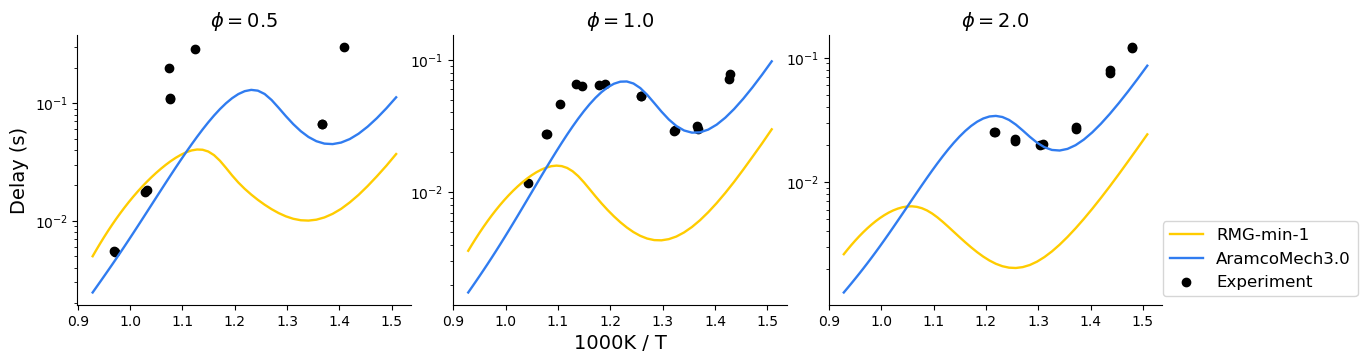

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

start_color = (1.0, 0.8, 0.0)
end_color = mcolors.hex2color(mcolors.CSS4_COLORS['forestgreen'])
aramco_color = (0.18627451, 0.48823529, 0.94117647)
colors = sns.blend_palette([start_color, end_color], n_colors=7, as_cmap=False, input='rgb')


for j, i in enumerate([4, 7, 10]):
    
    run0_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240126/table_{i:04}/base_delays_{i:04}.npy'
    run1_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240315/table_{i:04}/base_delays_{i:04}.npy'
    run2_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240403/table_{i:04}/base_delays_{i:04}.npy'
    run3_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240410/table_{i:04}/base_delays_{i:04}.npy'
    run4_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240416/table_{i:04}/base_delays_{i:04}.npy'
    run5_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240423/table_{i:04}/base_delays_{i:04}.npy'
    run6_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240501/table_{i:04}/base_delays_{i:04}.npy'
    
    lw = np.linspace(1.0, 2.0, 7)
    lw = [1.7 for x in range(7)]
    
    run0_delay = np.load(run0_npy)
    run1_delay = np.load(run1_npy)
    run2_delay = np.load(run2_npy)
    run3_delay = np.load(run3_npy)
    run4_delay = np.load(run4_npy)
    run5_delay = np.load(run5_npy)
    run6_delay = np.load(run6_npy)

    aramco_delay_npy = os.path.join('/work/westgroup/harris.se/autoscience/fuels/butane/official/aramco', f'table_{i:04}', f'base_delays_{i:04}.npy')
#     aramco_delay_npy = os.path.join(working_dir, 'aramco', f'table_{i:04}', f'base_delays_{i:04}.npy')
    aramco_delay = np.load(aramco_delay_npy)
    
    axes[j].plot(1000.0 / temperatures, run0_delay, label='RMG-min-1', color=colors[0], linewidth=lw[0])
#     axes[j].plot(1000.0 / temperatures, run1_delay, label='RMG-min-2', color=colors[1], linewidth=lw[1], linestyle='dashed')
#     axes[j].plot(1000.0 / temperatures, run2_delay, label='RMG-min-3', color=colors[2], linewidth=lw[2], linestyle='dashdot')
#     axes[j].plot(1000.0 / temperatures, run3_delay, label='RMG-min-4', color=colors[3], linewidth=lw[3], linestyle='solid')
#     axes[j].plot(1000.0 / temperatures, run4_delay, label='RMG-min-5', color=colors[4], linewidth=lw[4], linestyle='dashed')
#     axes[j].plot(1000.0 / temperatures, run5_delay, label='RMG-min-6', color=colors[5], linewidth=lw[5], linestyle='dashdot')
#     axes[j].plot(1000.0 / temperatures, run6_delay, label='RMG-min-7', color=colors[6], linewidth=lw[6])
    
    axes[j].plot(1000.0 / temperatures, run1_delay, label='_no_label', color=colors[1], linewidth=lw[1], alpha=0, linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, run2_delay, label='_no_label', color=colors[2], linewidth=lw[2], alpha=0, linestyle='dashdot')
    axes[j].plot(1000.0 / temperatures, run3_delay, label='_no_label', color=colors[3], linewidth=lw[3], alpha=0, linestyle='solid')
    axes[j].plot(1000.0 / temperatures, run4_delay, label='_no_label', color=colors[4], linewidth=lw[4], alpha=0, linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, run5_delay, label='_no_label', color=colors[5], linewidth=lw[5], alpha=0, linestyle='dashdot')
    axes[j].plot(1000.0 / temperatures, run6_delay, label='_no_label', color=colors[6], linewidth=lw[6], alpha=0)
    
    axes[j].plot(1000.0 / temperatures, aramco_delay, label='AramcoMech3.0', color=aramco_color, linewidth=lw[6])
    axes[j].spines[['right', 'top']].set_visible(False)

    # Scale the experimental delay by the pressure
    experiment_temperatures = df_exp[df_exp['Table'] == i]['T_C'].values
    experiment_delays = df_exp[df_exp['Table'] == i]['time (ms)'].values / 1000.0
    experiment_pressures_atm = df_exp[df_exp['Table'] == i]['chamber pressure? (bar)'].values * 100000 / 101325  # convert to atm
    nominal_pressures_atm = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values
    scaled_delays = np.zeros(len(experiment_delays))
    for k in range(len(experiment_temperatures)):
        scaled_delays[k] = scale_experimental_delay(experiment_delays[k], experiment_pressures_atm[k], nominal_pressures_atm[k], experiment_temperatures[k])
        
#     axes[j].scatter(1000.0 / experiment_temperatures, experiment_delays, label='Experiment', color='black') # Without scaling
    axes[j].scatter(1000.0 / experiment_temperatures, scaled_delays, label='Experiment', color='black')  # With scaling


    axes[j].set_yscale('log')
    
    
    phi = df_exp[df_exp['Table'] == i]['phi'].values[0]
    P0 = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values[0]
    axes[j].set_title(f'$\phi={phi}$', fontsize=14)
    

axes[1].set_xlabel('1000K / T', fontsize=14)
axes[0].set_ylabel('Delay (s)', fontsize=14)
plt.sca(axes[0])
plt.legend(loc='lower right', bbox_to_anchor=(3.86, 0), fontsize=12)
plt.subplots_adjust(wspace=0.125, hspace=None)

plt.savefig('RMG-min_delays.pdf', bbox_inches='tight')


# Plot RMG-MAX Delays

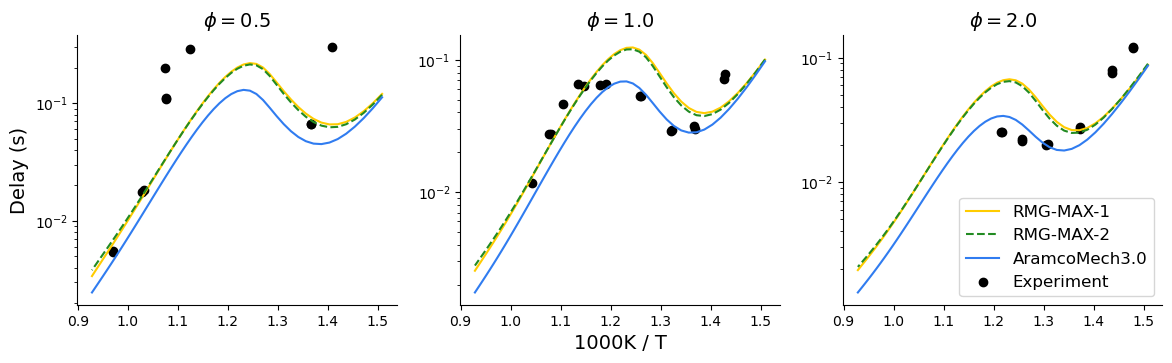

In [10]:
# read im the 12 datasets
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

P = 10
colors = [matplotlib.colormaps['viridis'].colors[:: -1][int(i / P * matplotlib.colormaps['viridis'].N)] for i in range(P)]
colors[0] = matplotlib.colormaps['viridis'].colors[:: -1][0]
colors[1] = matplotlib.colormaps['viridis'].colors[:: -1][30]
colors[2] = matplotlib.colormaps['viridis'].colors[:: -1][50]
colors[3] = matplotlib.colormaps['viridis'].colors[:: -1][90]
colors[4] = matplotlib.colormaps['viridis'].colors[:: -1][140]
colors[5] = matplotlib.colormaps['viridis'].colors[:: -1][190]
colors[6] = matplotlib.colormaps['viridis'].colors[:: -1][255]


start_color = mcolors.hex2color(mcolors.CSS4_COLORS['yellow'])  # make it yellow, but fade it 70% with alpha
start_color = (1.0, 0.8, 0.0)
end_color = mcolors.hex2color(mcolors.CSS4_COLORS['forestgreen'])
aramco_color = (0.18627451, 0.48823529, 0.94117647)
colors = sns.blend_palette([start_color, end_color], n_colors=7, as_cmap=False, input='rgb')



fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for j, i in enumerate([4, 7, 10]):
    
    run0_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/with_lib/butane_20240401/table_{i:04}/base_delays_{i:04}.npy'
    run1_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/with_lib/butane_20240413/table_{i:04}/base_delays_{i:04}.npy'
    
    
    
    run0_delay = np.load(run0_npy)
    run1_delay = np.load(run1_npy)

    aramco_delay_npy = os.path.join(working_dir, 'aramco', f'table_{i:04}', f'base_delays_{i:04}.npy')
    aramco_delay = np.load(aramco_delay_npy)
    
    axes[j].plot(1000.0 / temperatures, run0_delay, label='RMG-MAX-1', color=start_color, linestyle='solid')
    axes[j].plot(1000.0 / temperatures, run1_delay, label='RMG-MAX-2', color=end_color, linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, aramco_delay, label='AramcoMech3.0', color=aramco_color)
    

    # Scale the experimental delay by the pressure
    experiment_temperatures = df_exp[df_exp['Table'] == i]['T_C'].values
    experiment_delays = df_exp[df_exp['Table'] == i]['time (ms)'].values / 1000.0
    experiment_pressures_atm = df_exp[df_exp['Table'] == i]['chamber pressure? (bar)'].values * 100000 / 101325  # convert to atm
    nominal_pressures_atm = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values
    scaled_delays = np.zeros(len(experiment_delays))
    for k in range(len(experiment_temperatures)):
        scaled_delays[k] = scale_experimental_delay(experiment_delays[k], experiment_pressures_atm[k], nominal_pressures_atm[k], experiment_temperatures[k])
    
    axes[j].spines[['right', 'top']].set_visible(False)
    
    
#     axes[j].scatter(1000.0 / experiment_temperatures, experiment_delays, label='Experiment', color='black')  # No scaling
    axes[j].scatter(1000.0 / experiment_temperatures, scaled_delays, label='Experiment', color='black')  # With Pressure Scaling
    axes[j].set_yscale('log')
    
    
    phi = df_exp[df_exp['Table'] == i]['phi'].values[0]
    P0 = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values[0]
    axes[j].set_title(f'$\phi={phi}$', fontsize=14)
    

axes[1].set_xlabel('1000K / T', fontsize=14)
axes[0].set_ylabel('Delay (s)', fontsize=14)
plt.sca(axes[0])

axes[2].legend(fontsize=12)

plt.savefig('RMG-MAX_delays.pdf', bbox_inches='tight')